In [8]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt


con = duckdb.connect('../capillary.db')
df = con.execute("""
                SELECT p.row_id,
                    any_value(u_albumin_krea) as u_albumin,
                    any_value(u_igg_krea) as u_igg,
                    any_value(u_kappa_krea) as u_kappa,
                    any_value(u_lambda_krea) as u_lambda,
                    any_value(u_hc_krea) as u_hc,
                    list(c.comment_nr) as comment_nr,
                FROM protein_data p
                LEFT JOIN comment_precences c 
                    ON p.row_id = c.row_id
                GROUP BY p.row_id
                 """).df()

con.close()
urine_cols = ['u_albumin', 'u_igg', 'u_kappa', 'u_lambda', 'u_hc']
df['urine_sum'] = df[urine_cols].sum(axis=1)

comment_ids = [802, 805, 806, 807]
comment_dfs = {i: df[df['comment_nr'].apply(lambda x: i in x)] for i in comment_ids}

for id in comment_ids:
    print(len(comment_dfs[id]))


10146
7384
4496
342


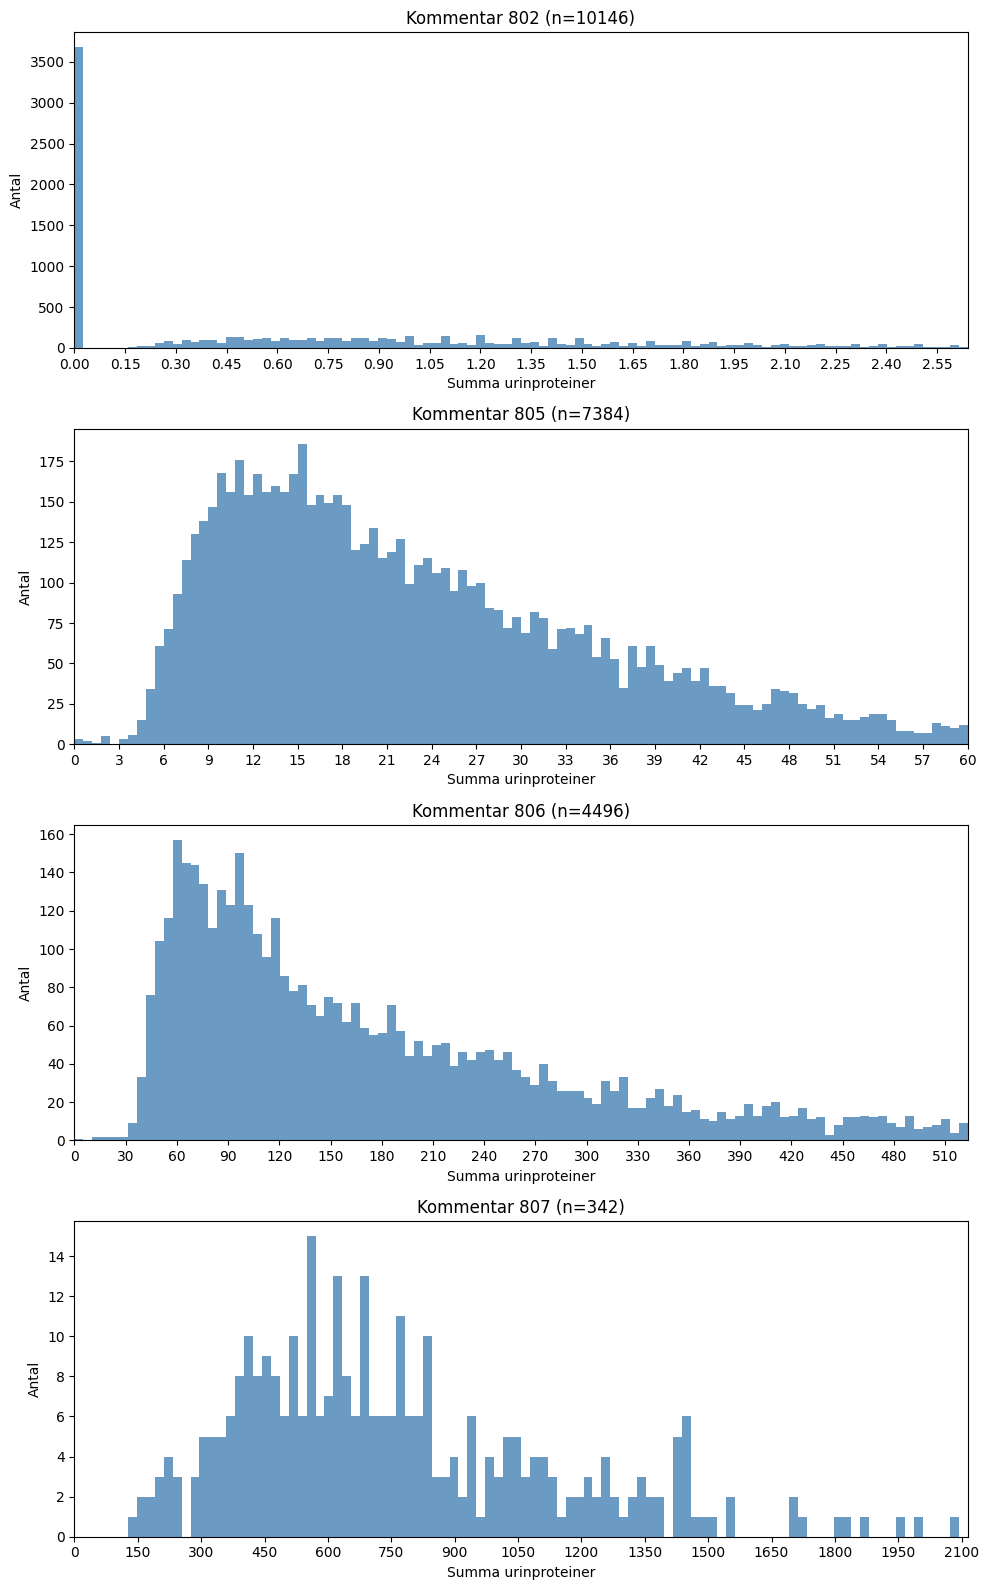

In [9]:
fig, axes = plt.subplots(len(comment_ids), 1, figsize=(10, 4 * len(comment_ids)))

for ax, comment_id in zip(axes, comment_ids):
    data = df[df['comment_nr'].apply(lambda x: comment_id in x)]['urine_sum'].dropna()
    x_max = data.quantile(0.95)  # Percentil per kommentar
    ax.hist(data, bins=100, color='steelblue', alpha=0.8, range=(0, x_max))
    ax.set_xlim(0, x_max)
    ax.set_title(f'Kommentar {comment_id} (n={len(data)})')
    ax.set_xlabel('Summa urinproteiner')
    ax.set_ylabel('Antal')
    ax.xaxis.set_major_locator(plt.MaxNLocator(20))  # 20 ticks på x-axeln


plt.tight_layout()
plt.show()

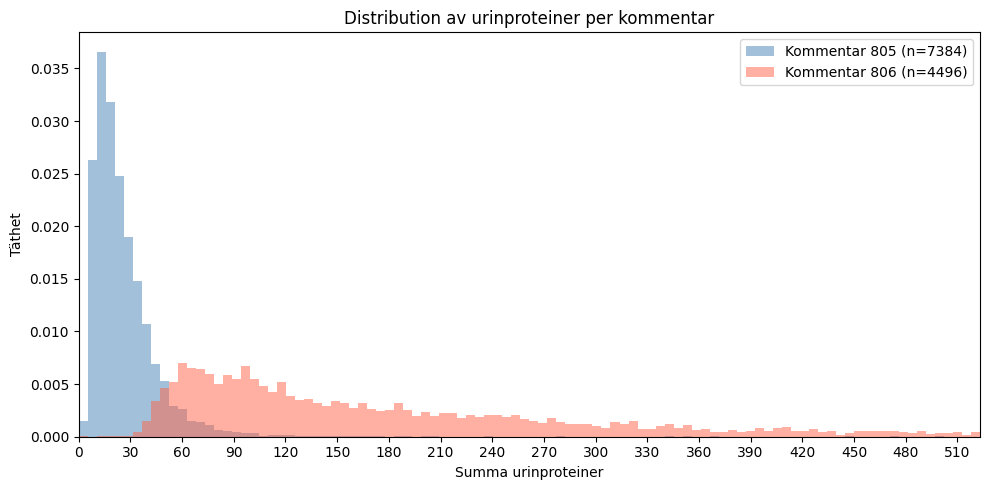

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['steelblue', 'tomato']
selected = [805, 806]

all_data = [df[df['comment_nr'].apply(lambda x: comment_id in x)]['urine_sum'].dropna() 
            for comment_id in selected]
x_max = max(data.quantile(0.95) for data in all_data)

for data, comment_id, color in zip(all_data, selected, colors):
    ax.hist(data, bins=100, alpha=0.5, color=color,
            label=f'Kommentar {comment_id} (n={len(data)})',
            density=True,
            range=(0, x_max))

ax.set_xlim(0, x_max)
ax.set_xlabel('Summa urinproteiner')
ax.set_ylabel('Täthet')
ax.set_title('Distribution av urinproteiner per kommentar')
ax.xaxis.set_major_locator(plt.MaxNLocator(20))  # 20 ticks på x-axeln

ax.legend()
plt.tight_layout()
plt.show()

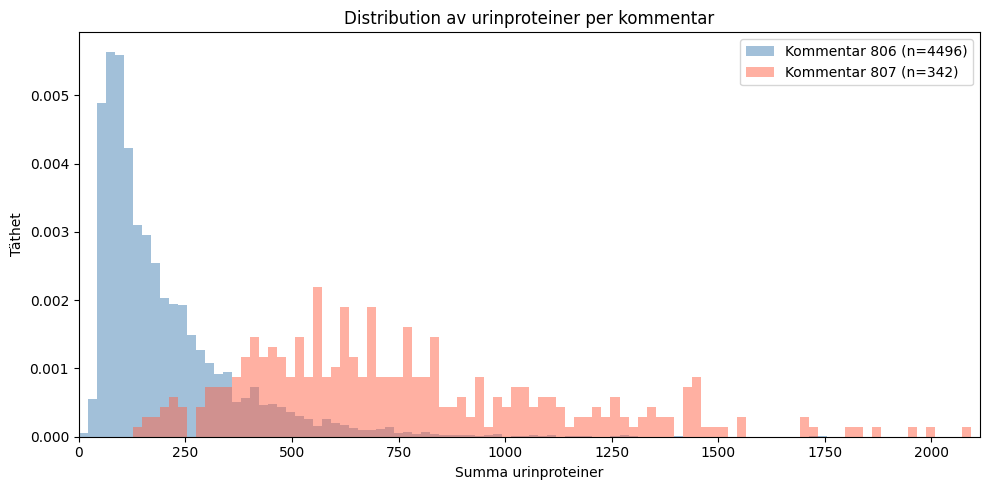

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['steelblue', 'tomato']
selected = [806, 807]

all_data = [df[df['comment_nr'].apply(lambda x: comment_id in x)]['urine_sum'].dropna() 
            for comment_id in selected]
x_max = max(data.quantile(0.95) for data in all_data)

for data, comment_id, color in zip(all_data, selected, colors):
    ax.hist(data, bins=100, alpha=0.5, color=color,
            label=f'Kommentar {comment_id} (n={len(data)})',
            density=True,
            range=(0, x_max))

ax.set_xlim(0, x_max)
ax.set_xlabel('Summa urinproteiner')
ax.set_ylabel('Täthet')
ax.set_title('Distribution av urinproteiner per kommentar')
ax.legend()
plt.tight_layout()
plt.show()